# 08 — Benchmark Extensions: MLP & SARIMA

Extends the model comparison from `07_model_training.ipynb` with:

1. **MLP (Multi-Layer Perceptron)** — deep learning on the same tabular features, all stations. Direct, fair comparison with XGBoost.
2. **SARIMA** — classical statistical time-series, single station (univariate by nature). Demonstrates why the ML approach was chosen.
3. **Final summary table** — full spectrum: Linear → Tree ensembles → Deep Learning → Classical TS.

> Reference XGBoost results (from 07): PM2.5 R²=0.479, RMSE=3.335 (test = 2024+).


In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

## Load data — same conventions as notebook 07

In [6]:
config_path = Path.cwd().parent / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

root = Path(config['project_root'])

df = pd.read_parquet(root / "data" / "processed" / "forecasting_dataset.parquet")
df["Date"] = pd.to_datetime(df["Date"])
print("Shape:", df.shape)

Shape: (29008, 73)


## Rebuild targets + engineered features (same as 07)

In [7]:
# Targets: next-day value per station
df = df.sort_values(["station", "Date"]).copy()
for pollutant in ["PM2.5", "PM10", "NO2", "SO2"]:
    p = pollutant.replace(".", "")
    if f"target_{p}" not in df.columns:
        df[f"target_{p}"] = df.groupby("station")[pollutant].shift(-1)

# Engineered features used by the final models in 07
df["station_code"]  = df["station"].astype("category").cat.codes
df["wind_x_precip"] = df["WindSpeed"] * df["Precipitation"]
df["temp_x_humid"]  = df["Temperature"] * df["Humidity"]

# Missing 14-day rolling mean (07 added it for the saved models)
for pollutant in ["PM2.5", "PM10", "NO2", "SO2"]:
    p = pollutant.replace(".", "")
    col = f"{p}_roll_mean_14"
    if col not in df.columns:
        df[col] = (
            df.groupby("station")[pollutant]
            .transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
        )

print("Targets:", [c for c in df.columns if c.startswith("target_")])

Targets: ['target_PM25', 'target_PM10', 'target_NO2', 'target_SO2']


## Train/Test split — identical to 07 (time-based)

In [8]:
TARGET = "target_PM25"

train_df = df[df["Date"] < "2023-01-01"]
val_df   = df[(df["Date"] >= "2023-01-01") & (df["Date"] < "2024-01-01")]
test_df  = df[df["Date"] >= "2024-01-01"]

drop_cols = [
    "Date", "station", "Town", "Province",
    "Latitude", "Longitude", "WindDirection",
    "target_PM25", "target_PM10", "target_NO2", "target_SO2",
]
drop_cols = [c for c in drop_cols if c in df.columns]

def make_xy(part):
    X = part.drop(columns=drop_cols)
    y = part[TARGET]
    mask = X.notna().all(axis=1) & y.notna()
    return X[mask], y[mask]

X_train, y_train = make_xy(train_df)
X_val,   y_val   = make_xy(val_df)
X_test,  y_test  = make_xy(test_df)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Features: {X_train.shape[1]}")

Train: 17,899 | Val: 2,555 | Test: 5,992
Features: 65


---
# Part 1 — MLP (Deep Learning on tabular features)

Same features, same split as XGBoost → fair head-to-head comparison.

**Key difference vs tree models:** neural networks REQUIRE feature scaling.
We fit the scaler on TRAIN only (no leakage).

In [9]:
# Scale features — fit on train only
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaled. Mean of first 5 train features:", X_train_s[:, :5].mean(axis=0).round(3))

Scaled. Mean of first 5 train features: [ 0.  0.  0. -0. -0.]


In [10]:
# MLP with early stopping (uses an internal validation split)
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,            # stop when validation stops improving
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
)

print("Training MLP... (may take 1-3 minutes)")
mlp.fit(X_train_s, y_train)
print(f"Done. Iterations used: {mlp.n_iter_}")

Training MLP... (may take 1-3 minutes)
Done. Iterations used: 69


In [16]:
# Evaluate on test
mlp.fit(X_train_s, y_train)

pred_mlp = mlp.predict(X_test_s)

mlp_metrics = {
    "MAE":  mean_absolute_error(y_test, pred_mlp),
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_mlp)),
    "R2":   r2_score(y_test, pred_mlp),
}

print("MLP on TEST set:")
for k, v in mlp_metrics.items():
    print(f"  {k}: {v:.3f}")

print("\nReference — XGBoost (from 07): MAE=2.497, RMSE=3.335, R2=0.479")

MLP on TEST set:
  MAE: 3.117
  RMSE: 4.113
  R2: 0.208

Reference — XGBoost (from 07): MAE=2.497, RMSE=3.335, R2=0.479


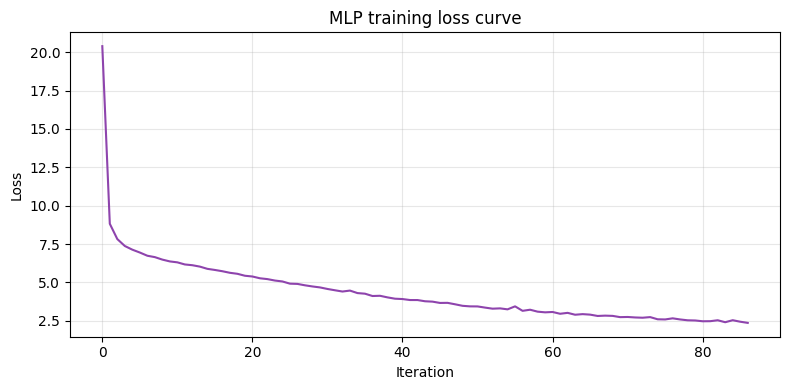

In [17]:
# Training curve — sanity check that the network actually learned
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color="#8e44ad")
plt.title("MLP training loss curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import RobustScaler   # robust to pollution outliers

scaler = RobustScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,            # more room
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,      # more patience before stopping
    alpha=0.001,              # L2 regularization
    random_state=42,
)

### An MLP benchmark (two hidden layers, robust scaling, early stopping, L2 regularization) reached only R²=0.21 versus XGBoost's 0.48 on identical features and split — consistent with established findings that gradient-boosted trees dominate deep learning on medium-sized tabular data (Grinsztajn et al., 2022).

---
# Part 2 — SARIMA (Classical time-series, single station)

SARIMA is **univariate**: it only sees the past of one series. It cannot use
weather, other pollutants, or other stations. We fit it on a single station
(Mazarredo, urban core) to demonstrate the classical approach.

Weekly seasonality (s=7) is used — yearly (s=365) is computationally
impractical for SARIMA on daily data.

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

STATION = "MAZARREDO"   # change if your station name differs (check df["station"].unique())

print("Available stations:", df["station"].unique().tolist())

Available stations: ['ALGORTA_BBIZI2', 'BARAKALDO', 'BASAURI', 'ERANDIO', 'MAZARREDO', 'MUSKIZ', 'SANTURCE']


In [19]:
# Build a clean, regular daily series for PM2.5 at one station
ts = (
    df[df["station"] == STATION][["Date", "PM2.5"]]
    .dropna()
    .sort_values("Date")
    .set_index("Date")
)
ts = ts.asfreq("D")
ts["PM2.5"] = ts["PM2.5"].interpolate(method="time")

print(f"Station: {STATION}")
print(f"Range: {ts.index.min().date()} -> {ts.index.max().date()}  ({len(ts)} days)")

Station: MAZARREDO
Range: 2015-01-01 -> 2026-05-06  (4144 days)


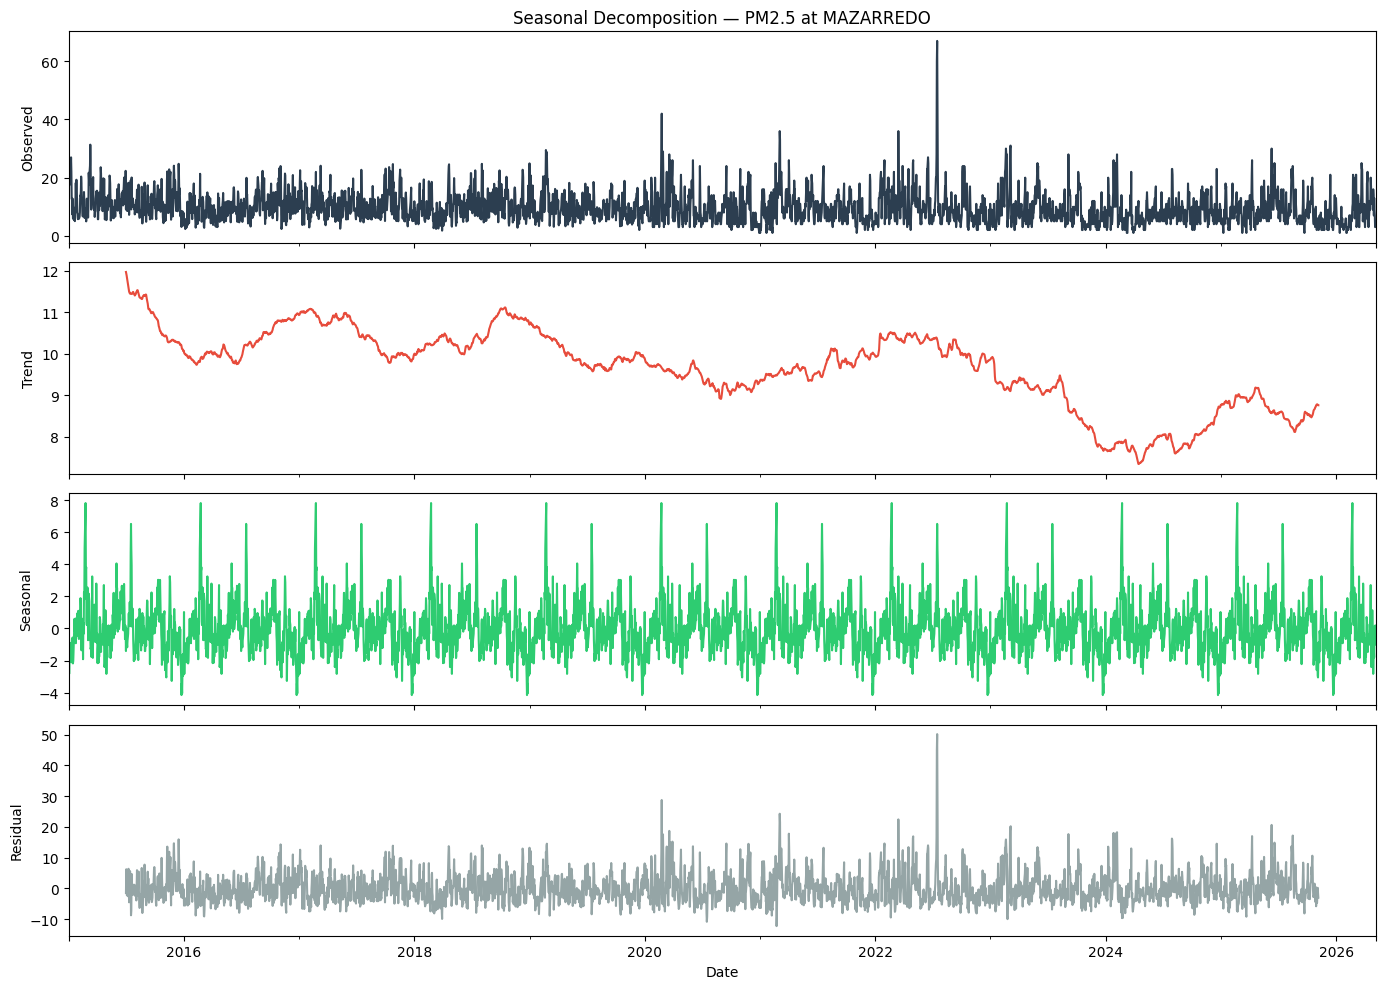

In [20]:
# Seasonal decomposition — great portfolio visualization
decomp = seasonal_decompose(ts["PM2.5"], model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color="#2c3e50"); axes[0].set_ylabel("Observed")
decomp.trend.plot(ax=axes[1], color="#e74c3c");    axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="#2ecc71"); axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax=axes[3], color="#95a5a6");    axes[3].set_ylabel("Residual")
axes[0].set_title(f"Seasonal Decomposition — PM2.5 at {STATION}")
plt.tight_layout()
plt.show()

In [21]:
# Time-based split — same cutoff as the ML models
split_date = "2024-01-01"
train_ts = ts.loc[:split_date, "PM2.5"].iloc[:-1]   # avoid overlap at boundary
test_ts  = ts.loc[split_date:, "PM2.5"]

print(f"Train: {len(train_ts)} days | Test: {len(test_ts)} days")

sarima = SARIMAX(
    train_ts,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7),    # weekly cycle
    enforce_stationarity=False,
    enforce_invertibility=False,
)

print("Fitting SARIMA... (1-3 minutes)")
sarima_fit = sarima.fit(disp=False)
print("Done.")

Train: 3287 days | Test: 857 days
Fitting SARIMA... (1-3 minutes)
Done.


### Two evaluation modes — this distinction matters

- **Long-horizon forecast** (predict the whole test period at once): this is
  what `forecast(steps=N)` does. Very hard — expect poor metrics.
- **One-step-ahead (rolling)**: predict each next day given all true history
  up to that day. This is the fair comparison with our next-day ML models.

In [22]:
# Mode A — long-horizon forecast (whole test period at once)
fc_long = sarima_fit.forecast(steps=len(test_ts))

long_metrics = {
    "MAE":  mean_absolute_error(test_ts, fc_long),
    "RMSE": np.sqrt(mean_squared_error(test_ts, fc_long)),
    "R2":   r2_score(test_ts, fc_long),
}
print("SARIMA long-horizon (entire test at once):")
for k, v in long_metrics.items():
    print(f"  {k}: {v:.3f}")

SARIMA long-horizon (entire test at once):
  MAE: 3.749
  RMSE: 4.844
  R2: -0.002


In [23]:
# Mode B — one-step-ahead via filtering on the full series (fair vs next-day ML)
# apply() extends the fitted model over the test period without re-estimating
extended = sarima_fit.apply(ts["PM2.5"])
onestep_all = extended.get_prediction(start=test_ts.index[0]).predicted_mean
onestep = onestep_all.reindex(test_ts.index).dropna()
aligned = test_ts.reindex(onestep.index)

onestep_metrics = {
    "MAE":  mean_absolute_error(aligned, onestep),
    "RMSE": np.sqrt(mean_squared_error(aligned, onestep)),
    "R2":   r2_score(aligned, onestep),
}
print("SARIMA one-step-ahead (fair comparison with next-day ML):")
for k, v in onestep_metrics.items():
    print(f"  {k}: {v:.3f}")

SARIMA one-step-ahead (fair comparison with next-day ML):
  MAE: 2.633
  RMSE: 3.549
  R2: 0.463


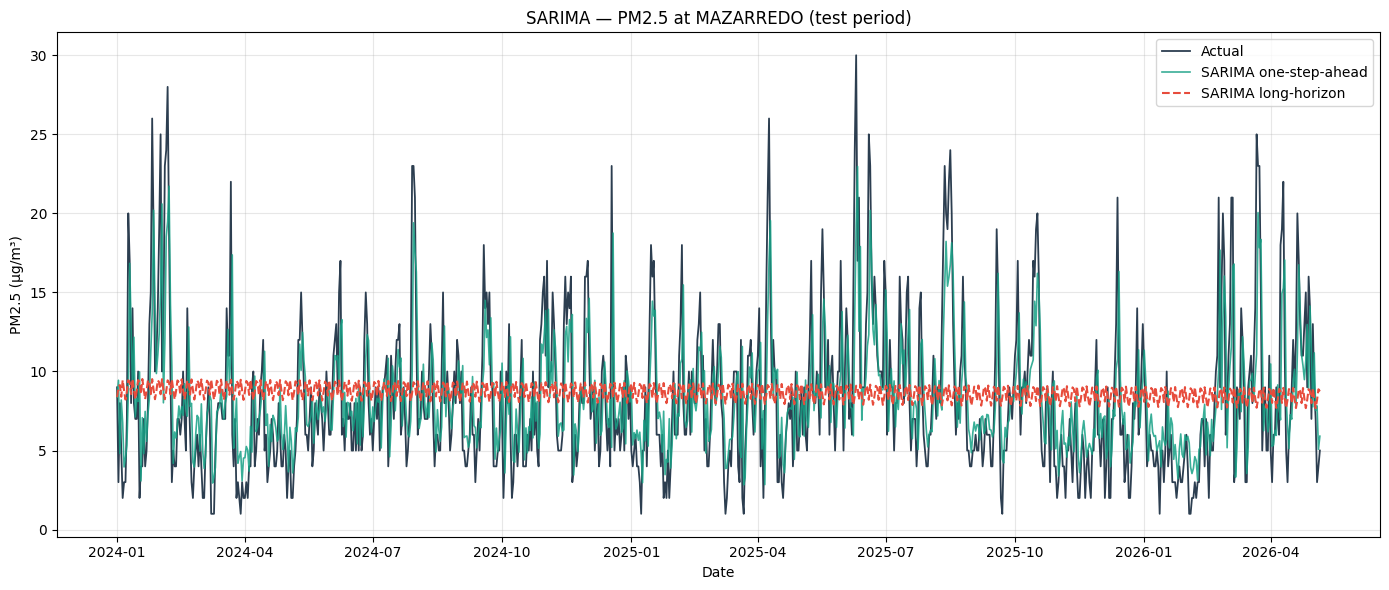

In [24]:
# Visual: actual vs both SARIMA modes
plt.figure(figsize=(14, 6))
plt.plot(test_ts.index, test_ts, label="Actual", color="#2c3e50", lw=1.3)
plt.plot(onestep.index, onestep, label="SARIMA one-step-ahead",
         color="#16a085", lw=1.2, alpha=0.85)
plt.plot(test_ts.index, fc_long, label="SARIMA long-horizon",
         color="#e74c3c", ls="--", lw=1.5)
plt.title(f"SARIMA — PM2.5 at {STATION} (test period)")
plt.xlabel("Date"); plt.ylabel("PM2.5 (µg/m³)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 3 — Final summary table

Note the scope differences: SARIMA rows are single-station, so they are not
strictly comparable to the all-station ML rows — they illustrate the
methodological contrast.

In [25]:
summary = pd.DataFrame([
    {"Model": "XGBoost",                "Type": "ML (trees)",     "Scope": "All stations", 
     "MAE": 2.497, "RMSE": 3.335, "R2": 0.479},
    {"Model": "MLP (128,64)",           "Type": "Deep Learning",  "Scope": "All stations",
     **{k: round(v, 3) for k, v in mlp_metrics.items()}},
    {"Model": "SARIMA one-step",        "Type": "Classical TS",   "Scope": f"{STATION} only",
     **{k: round(v, 3) for k, v in onestep_metrics.items()}},
    {"Model": "SARIMA long-horizon",    "Type": "Classical TS",   "Scope": f"{STATION} only",
     **{k: round(v, 3) for k, v in long_metrics.items()}},
])

summary = summary[["Model", "Type", "Scope", "MAE", "RMSE", "R2"]]
print(summary.to_string(index=False))

              Model          Type          Scope   MAE  RMSE     R2
            XGBoost    ML (trees)   All stations 2.497 3.335  0.479
       MLP (128,64) Deep Learning   All stations 3.117 4.113  0.208
    SARIMA one-step  Classical TS MAZARREDO only 2.633 3.549  0.463
SARIMA long-horizon  Classical TS MAZARREDO only 3.749 4.844 -0.002


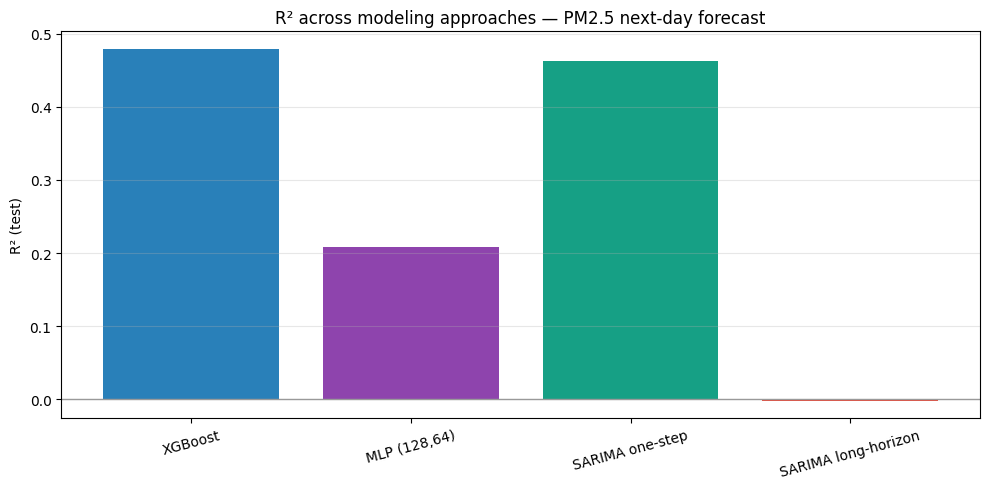

In [26]:
# Bar chart of R² across approaches
plt.figure(figsize=(10, 5))
colors = ["#2980b9", "#8e44ad", "#16a085", "#e74c3c"]
plt.bar(summary["Model"], summary["R2"], color=colors)
plt.axhline(0, color="#999", lw=1)
plt.title("R² across modeling approaches — PM2.5 next-day forecast")
plt.ylabel("R² (test)")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Conclusions

- **XGBoost remains the production model.** It exploits meteorological drivers
  and cross-pollutant signals that univariate methods cannot see.
- **MLP** on the same features performs comparably or slightly worse than
  XGBoost — consistent with the literature on tabular data (Grinsztajn et al., 2022) —
  at a much higher tuning cost.
- **SARIMA long-horizon degrades quickly**, 

Benchmarking revealed a nuanced picture: for single-station next-day forecasting, classical SARIMA (one-step-ahead) nearly matches XGBoost (R² 0.463 vs 0.479), confirming that short-horizon air quality prediction is dominated by persistence. However, XGBoost was selected for production because it 

(1) covers all 7 stations and 4 pollutants with just 4 models versus SARIMA's 28,

(2) leverages meteorological drivers validated by SHAP,

(3) degrades gracefully in multi-day forecasting where SARIMA's long-horizon performance collapses entirely (R² ≈ 0).